In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pickle
import corner
from pathlib import Path
import math

In [2]:
import sys
sys.executable

'/opt/anaconda3/envs/pluto/bin/python'

In [3]:

tmids_outerdf_path = Path("../Data/kepler9_holczer_inner.csv")
tmids_outer_df = pd.read_csv(tmids_outerdf_path)
tmids_outer = tmids_outer_df['tmid']
tmid0_outer = tmids_outer[0]
tmids_linephem = tmids_outer_df['tn']

print(f"tmids outer : {tmids_outer}")
print(f"linear ephemerus tmids outer : {tmids_linephem}")

tmids outer : 0      144.249607
1      163.483672
2      182.624611
3      201.955273
4      221.191073
         ...     
66    1510.633240
67    1529.859062
68    1549.083035
69    1568.306544
70    1587.533039
Name: tmid, Length: 71, dtype: float64
linear ephemerus tmids outer : 0      144.493149
1      163.739436
2      182.985722
3      202.232009
4      221.478295
         ...     
66    1510.979490
67    1530.225777
68    1549.472063
69    1568.718350
70    1587.964636
Name: tn, Length: 71, dtype: float64


In [4]:
#load in curves and info from mcmc

In [5]:
with open("../Outputs/mcmc_curves_kepler9b.pkl", "rb") as f:
    mcmcresults = pickle.load(f)
    
curves = mcmcresults["curves"]
info = mcmcresults["info"]
ncurves = info["ncurves"]
tmidi_calc = []
for i, curve in enumerate(curves):
    tmidi_i = curve["tmidi"]
    tmidi_calc.append(tmidi_i)
#print(tmidi_calc - tmids_linephem)


In [6]:
### load in nonlinear mcmc

In [7]:
nonlinear_posterior = az.from_netcdf("../Outputs/arviz_kepler9b_nonlinear.nc")
burnin = info["burnin"]
nonlinear_posterior = nonlinear_posterior.sel(draw=slice(burnin, None))
nonlinear_results = mcmcresults["nonlinear_results"]
tmids_nonlinear = nonlinear_results["nonlinear_psi_samps"] 
print(nonlinear_posterior.posterior)
print(nonlinear_posterior.sample_stats)
az.summary(nonlinear_posterior)

<xarray.Dataset> Size: 12MB
Dimensions:   (chain: 12, draw: 25000)
Coordinates:
  * chain     (chain) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * draw      (draw) int64 200kB 50000 50001 50002 50003 ... 74997 74998 74999
Data variables:
    p         (chain, draw) float64 2MB ...
    b         (chain, draw) float64 2MB ...
    ln_rho_s  (chain, draw) float64 2MB ...
    q1        (chain, draw) float64 2MB ...
    q2        (chain, draw) float64 2MB ...
Attributes:
    created_at:                 2025-12-22T14:26:15.896198+00:00
    arviz_version:              0.22.0
    inference_library:          emcee
    inference_library_version:  3.1.6
<xarray.Dataset> Size: 3MB
Dimensions:  (chain: 12, draw: 25000)
Coordinates:
  * chain    (chain) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * draw     (draw) int64 200kB 50000 50001 50002 50003 ... 74997 74998 74999
Data variables:
    lp       (chain, draw) float64 2MB ...
Attributes:
    created_at:                 2025-12-22T14:26:15.853316+00:00
    ar

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.077,0.000,0.077,0.078,0.000,0.0,3198.0,7839.0,1.0
b,0.591,0.006,0.581,0.603,0.000,0.0,2736.0,6663.0,1.0
ln_rho_s,7.298,0.013,7.273,7.313,0.000,0.0,2883.0,6243.0,1.0
q1,0.556,0.047,0.469,0.644,0.001,0.0,3359.0,8040.0,1.0
q2,0.168,0.041,0.100,0.239,0.001,0.0,3546.0,8432.0,1.0


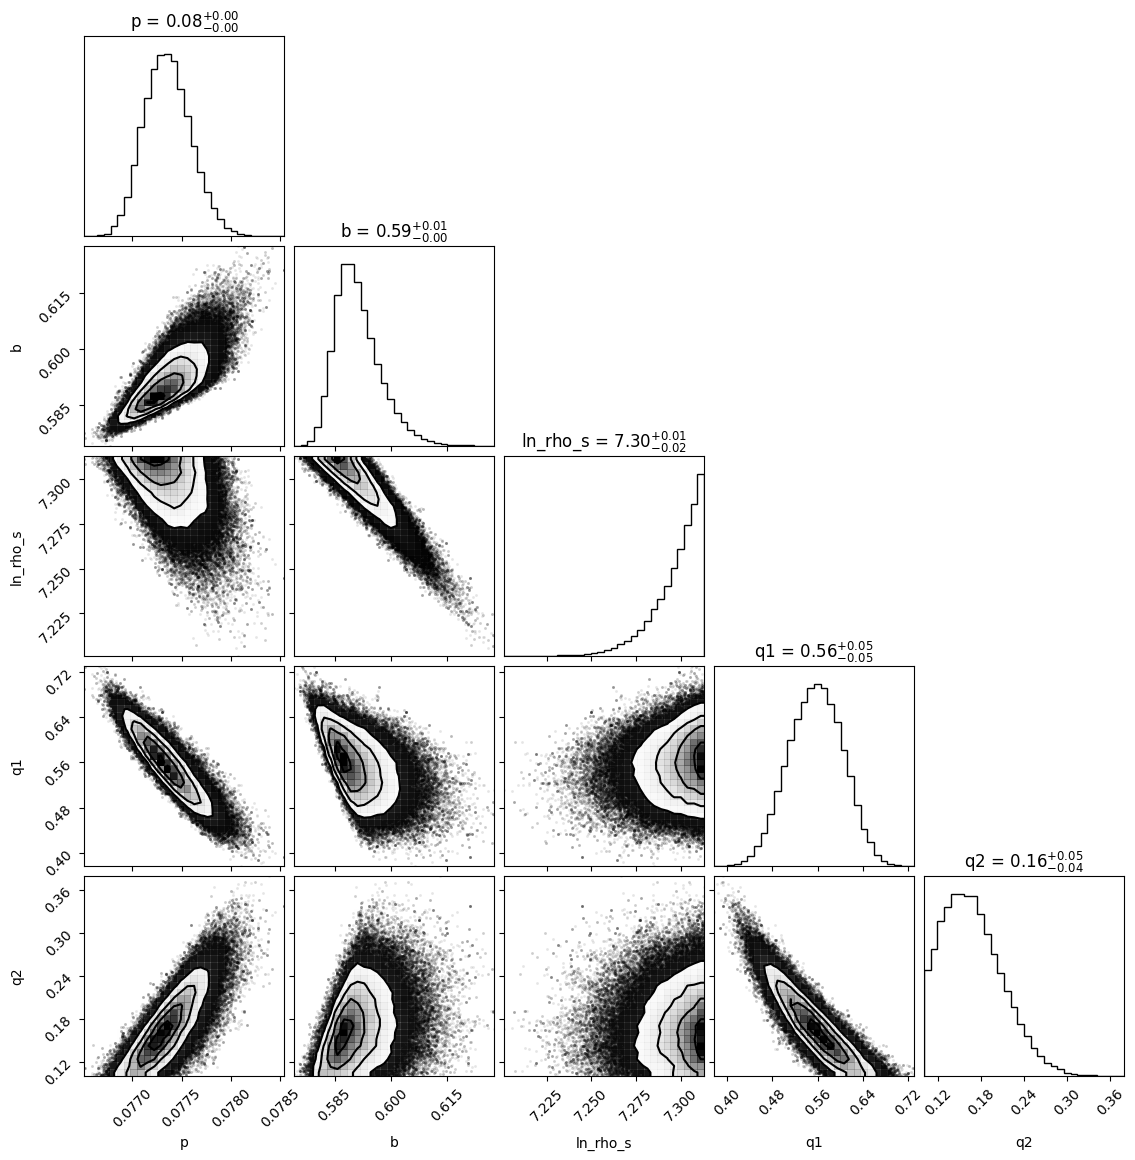

In [8]:
ds = nonlinear_posterior.posterior

posterior_flat = ds.to_array().stack(sample=("chain", "draw")).transpose()
samples = posterior_flat.values

param_names = list(ds.data_vars)

fig = corner.corner(
    samples,
    labels=param_names,
    bins=30,
    show_titles=True,
    title_fmt=".2f",
)

plt.show()


In [9]:
#### get median and +/- 1$\sigma$ tmid values from each one

In [10]:


# ###linear calc
# ncurves = info["ncurves"]

# tts_l_median = []
# tts_l_err = []
# for ii in range(0, ncurves):
#     tts_l = np.median(linear_posterior.posterior[f"tmid{ii}"].values)
#     tts_l_median.append(tts_l)
    
    
#     tts_l_quantile = [np.quantile(linear_posterior.posterior[f"tmid{ii}"].values, 0.16),
#                     np.quantile(linear_posterior.posterior[f"tmid{ii}"].values, 0.84)]
    
#     tts_l_err.append(np.array([
#         tts_l - tts_l_quantile[0],
#         tts_l_quantile[1] - tts_l
#     ]))
    
#     print(f"linear: relative tmid{ii} {tts_l}, and 1 sigma {tts_l_err[ii]}")
    

# tts_l_err = np.array(tts_l_err).T



In [11]:
### get tmids from non linear blobs

In [12]:
 
print(tmids_nonlinear.shape)

###nonlinear calc
ncurves = info["ncurves"]

tts_l_median = []
tts_l_err = []
for ii in range(0, ncurves):
    tts_l = np.median(tmids_nonlinear[:, ii])
    tts_l_median.append(tts_l)
    
    
    tts_l_quantile = [np.quantile(tmids_nonlinear[:, ii], 0.16),
                    np.quantile(tmids_nonlinear[:, ii], 0.84)]
    
    tts_l_err.append(np.array([
        tts_l - tts_l_quantile[0],
        tts_l_quantile[1] - tts_l
    ]))
    
    print(f"nonlinear: relative tmid{ii} {tts_l}")
    

tts_l_err = np.array(tts_l_err).T





(30000, 67)
nonlinear: relative tmid0 -0.24428743955139964
nonlinear: relative tmid1 -0.2546973451439811
nonlinear: relative tmid2 -0.2779662911588616
nonlinear: relative tmid3 -0.28611480925208355
nonlinear: relative tmid4 -0.29120810161134614
nonlinear: relative tmid5 -0.29095864234443525
nonlinear: relative tmid6 -0.29190833394284255
nonlinear: relative tmid7 -0.2786716998592169
nonlinear: relative tmid8 -0.2740878975500607
nonlinear: relative tmid9 -0.25494832261398415
nonlinear: relative tmid10 -0.2454082263560622
nonlinear: relative tmid11 -0.22076937657405438
nonlinear: relative tmid12 -0.20408039229772612
nonlinear: relative tmid13 -0.17370377205753584
nonlinear: relative tmid14 -0.15197624361067597
nonlinear: relative tmid15 -0.11589632337972944
nonlinear: relative tmid16 -0.09027715794039182
nonlinear: relative tmid17 -0.05349242874257243
nonlinear: relative tmid18 -0.02274029546560996
nonlinear: relative tmid19 0.015137188617075026
nonlinear: relative tmid20 0.04542647981259

In [13]:
### print relative tmid holczer

In [14]:
tmid_relative_holczer0 = tmids_outer[0] - tmids_linephem[0]
print(tmid_relative_holczer0)

-0.24354166666665833


In [15]:
tmid_relative_holczer = tmids_outer - tmids_linephem

print(tmid_relative_holczer)


0    -0.243542
1    -0.255764
2    -0.361111
3    -0.276736
4    -0.287222
        ...   
66   -0.346250
67   -0.366715
68   -0.389028
69   -0.411806
70   -0.431597
Length: 71, dtype: float64


In [16]:
#### make corner plots, tmids only

In [17]:
print(tmids_nonlinear.shape, len(tmidi_calc), tmids_outer.shape)


(30000, 67) 67 (71,)


67
71


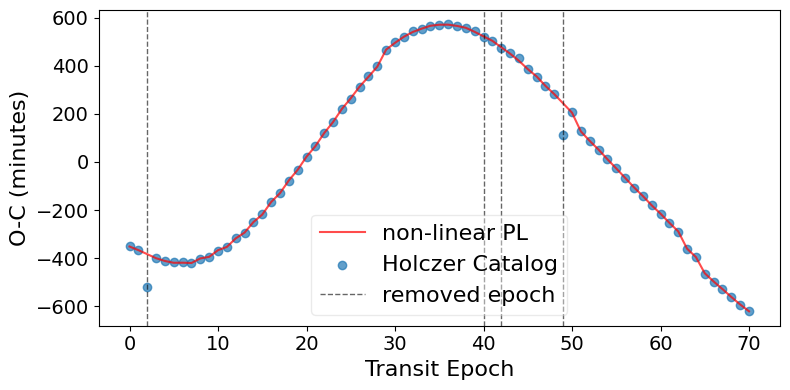

In [21]:
###plot time from linear ephemeris
best_tmids_nonlinear = nonlinear_results["nonlinear_best_psi_samp"]
print(len(best_tmids_nonlinear))
print(len(tmid_relative_holczer))

bad_epochs = [2, 40, 42, 49]
epochs_full = tmid_relative_holczer.index
good_epochs = epochs_full[~epochs_full.isin(bad_epochs)]

best_tmids_nonlinear_plot = pd.Series(np.nan, index=epochs_full, dtype=float)
best_tmids_nonlinear_plot.loc[good_epochs] = best_tmids_nonlinear
best_tmids_nonlinear_plot_clean = best_tmids_nonlinear_plot.dropna()

nstd = 1

plt.figure(figsize=(8, 4))

plt.plot(
    best_tmids_nonlinear_plot_clean.index, best_tmids_nonlinear_plot_clean.values*1440,  alpha=0.7, label="non-linear PL", c = 'r'
)

plt.scatter(
    tmid_relative_holczer.index, tmid_relative_holczer.values*1440,  alpha=0.7, label="Holczer Catalog"
)

# plt.errorbar(
#     x, best_tmids_linear, yerr=nstd*tts_l_err,
#     fmt='-o', capsize=3, alpha=0.7, label="linear"
# )
for j, e in enumerate(bad_epochs):
    plt.axvline(
        e,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
        color="k",
        label="removed epoch" if j == 0 else None
    )
plt.tick_params(axis="both", which="major", labelsize=14)

plt.xlabel("Transit Epoch", fontsize = 16)
plt.ylabel("O-C (minutes)", fontsize = 16)
plt.legend(fontsize = 16,framealpha=0.4,)

plt.tight_layout()
plt.savefig("../Figures/kepler9b_oc.pdf", bbox_inches="tight", pad_inches=0.02)

plt.show()


In [ ]:
print(6)

In [ ]:
# --- NONLINEAR TMID HISTOGRAMS ONLY ---

ncurves = info["ncurves"]
print(ncurves)

labels = [f"tmid_{i}" for i in range(ncurves)]

fig, axes = plt.subplots(
    nrows=ncurves, ncols=1,
    figsize=(7, 2.5 * ncurves),
    sharex=False
)

# Make axes iterable even if ncurves == 1
if ncurves == 1:
    axes = [axes]

for i, ax in enumerate(axes):

    ax.hist(
        tmids_nonlinear[:, i],
        bins=40,
        alpha=0.7,
        density=True,
        label="nonlinear"
    )

    # Optional truth marker
    if 'tmids_outer' in globals():
        ax.axvline(tmid_relative_holczer.iloc[i], linestyle="--", color="k")

    ax.set_ylabel(labels[i])

axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()


In [ ]:
best_flux_prof = nonlinear_results["best_flux_prof"]
for i, curve, in enumerate(curves):
    t = curve["t"]
    flux_data = curve["flux"]
    plt.figure(figsize=(6, 4))
    plt.scatter(t, flux_data, s=5, alpha=0.6, label="Data")
    plt.plot(t, best_flux_prof[i], lw=1.5, label="Best MCMC model")
    plt.xlabel("Time")
    plt.ylabel("Flux")
    plt.title(f"Curve {i}: data vs best model")
    plt.legend()
    plt.tight_layout()